# Data Exploration: Skin Lesion Segmentation

This notebook explores the ISIC 2018 dataset and visualizes sample images with their corresponding segmentation masks.

In [1]:
# Mount Google Drive (Google Colab only)
import sys

# Check if running on Google Colab or Local machine
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive has been mounted successfully")
    except Exception as e:
        print(f"Failed to mount Google Drive: {e}")
        IS_COLAB = False
else:
    print("Running on local machine (not Google Colab)")

Mounted at /content/drive
Google Drive has been mounted successfully


In [3]:
import os

# Handle src path for both local and Colab environments
if 'google.colab' in sys.modules:
    # Google Colab: src files are copied
    sys.path.insert(0, '/content/drive/MyDrive/CSCI 425/data/models/notebooks/src')
else:
    # Local machine: src is in the notebooks directory
    sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import torch
import matplotlib.pyplot as plt
from dataset import SegmentationDatasets
from utils import show_samples

/content/drive/MyDrive/CSCI 425/data/models/notebooks/src/dataset.py:57: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),


In [4]:
# Set up data paths
# Handle both local and Google Colab environments
if IS_COLAB:
    # Google Colab path - adjust the path to match your Drive structure
    # Example: /content/drive/MyDrive/path/
    base_dir = '/content/drive/MyDrive/CSCI 425/data/'
    print("Using Google Colab data path")
else:
    # Local machine path
    base_dir = os.path.join(os.getcwd(), '../../')
    print("Using local machine data path")

train_image_dir = os.path.join(base_dir, 'train/images')
train_mask_dir = os.path.join(base_dir, 'train/masks')
val_image_dir = os.path.join(base_dir, 'val/images')
val_mask_dir = os.path.join(base_dir, 'val/masks')

print(f"Training images: {train_image_dir}")
print(f"Training masks: {train_mask_dir}")
print(f"Validation images: {val_image_dir}")
print(f"Validation masks: {val_mask_dir}")

Using Google Colab data path
Training images: /content/drive/MyDrive/CSCI 425/data/train/images
Training masks: /content/drive/MyDrive/CSCI 425/data/train/masks
Validation images: /content/drive/MyDrive/CSCI 425/data/val/images
Validation masks: /content/drive/MyDrive/CSCI 425/data/val/masks


In [5]:
# Load training dataset without transforms to view original data
train_dataset = SegmentationDatasets(
    image_dir=train_image_dir,
    mask_dir=train_mask_dir,
    transform=None
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Sample image shape: {train_dataset[0][0].shape}")
print(f"Sample mask shape: {train_dataset[0][1].shape}")

Training dataset size: 2594
Sample image shape: (767, 1022, 3)
Sample mask shape: (767, 1022)


## Sample Images and Masks Visualization

Below are sample images from the training dataset with their corresponding segmentation masks:

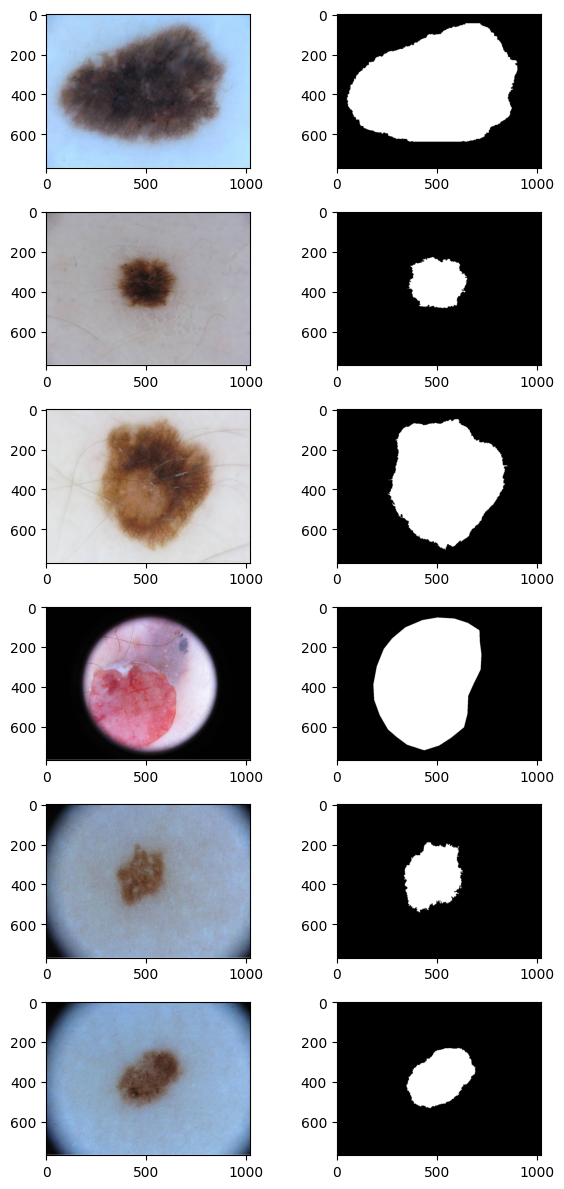

In [6]:
# Visualize sample images and masks from the training dataset
show_samples(train_dataset, n=6)

## Model Architecture: U-Net with ResNet-34 Encoder

Load a pretrained U-Net model using segmentation-models-pytorch library. The encoder uses ResNet-34 pretrained on ImageNet for transfer learning.

In [10]:
import segmentation_models_pytorch as smp

# Load pretrained U-Net with ResNet-34 encoder
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',  # Use ImageNet pretrained weights
    in_channels=3,                # RGB images
    classes=1                     # Binary segmentation (lesion vs non-lesion)
)

print(f"Model loaded successfully!")
print(f"Model type: {type(model)}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model loaded successfully!
Model type: <class 'segmentation_models_pytorch.decoders.unet.model.Unet'>
Model parameters: 24,436,369
Trainable parameters: 24,436,369


## Loss Function: Combined BCE + Dice Loss

For imbalanced segmentation tasks, we use a combined loss function that leverages both:
- **Binary Cross-Entropy (BCE)**: Handles pixel-level classification errors
- **Dice Loss**: Focuses on overall shape and overlap between predicted and target masks

This combination is particularly effective when the foreground (lesion) is much smaller than the background.

In [11]:
from loss import BCEWithDiceLoss, DiceLoss

# Initialize combined loss function with equal weighting (α = 0.5)
criterion = BCEWithDiceLoss(alpha=0.5)

print("Loss function initialized successfully!")
print(f"Loss function: {type(criterion).__name__}")
print(f"Alpha (BCE weight): {criterion.alpha}")
print(f"Dice weight: {1 - criterion.alpha}")

# Test the loss with dummy data
batch_size = 4
height, width = 256, 256

# Create dummy predictions and targets
dummy_pred = torch.randn(batch_size, 1, height, width)  # Logits
dummy_target = torch.randint(0, 2, (batch_size, 1, height, width)).float()  # Binary mask

# Compute loss
test_loss = criterion(dummy_pred, dummy_target)
print(f"\nTest loss computation: {test_loss.item():.4f}")
print("Loss function is working correctly!")

Loss function initialized successfully!
Loss function: BCEWithDiceLoss
Alpha (BCE weight): 0.5
Dice weight: 0.5

Test loss computation: 0.6526
Loss function is working correctly!


## Optimizer and Learning Rate Scheduler

Configure the Adam optimizer with an initial learning rate of 1e-4 and cosine annealing learning rate schedule for smooth learning rate decay during training.

In [12]:
# Training hyperparameters
initial_lr = 1e-4
num_epochs = 10 if IS_COLAB else 50  # Start with 10 epochs on Colab for testing, increase later
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"Using CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
Using CUDA: True
GPU: Tesla T4
GPU Memory: 15.64 GB


/tmp/ipykernel_429/2986826147.py:11: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  temp_scheduler.step()


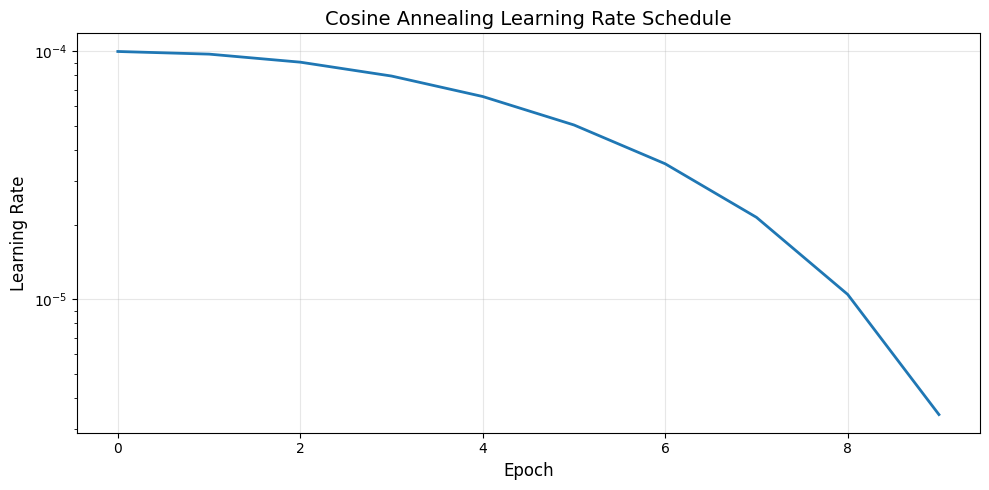

Learning rate schedule visualization complete!
Initial LR: 1.00e-04
Final LR: 3.42e-06


In [13]:
# Visualize learning rate schedule
lrs = []
temp_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    torch.optim.Adam(model.parameters(), lr=initial_lr),
    T_max=num_epochs,
    eta_min=1e-6
)

for epoch in range(num_epochs):
    lrs.append(temp_scheduler.get_last_lr()[0])
    temp_scheduler.step()

# Plot learning rate schedule
plt.figure(figsize=(10, 5))
plt.plot(lrs, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Cosine Annealing Learning Rate Schedule', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"Learning rate schedule visualization complete!")
print(f"Initial LR: {lrs[0]:.2e}")
print(f"Final LR: {lrs[-1]:.2e}")

In [14]:
# Initialize optimizer and learning rate scheduler for training
# (Note: Create fresh optimizer after visualizing the schedule)
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

print(f"\nOptimizer and scheduler initialized for training!")


Optimizer and scheduler initialized for training!


In [15]:
# GPU Memory Optimization (important for Google Colab)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared")
    
    # Set mixed precision for faster training (optional, helps with memory)
    # torch.cuda.amp.autocast(enabled=True)
    
print(f"All components ready for training!")
print(f"Starting GPU training on device: {device}")

CUDA cache cleared
All components ready for training!
Starting GPU training on device: cuda


In [17]:
# Copy src files from Google Drive to Colab runtime
import shutil

if IS_COLAB:
    print("Copying src files from Google Drive to Colab runtime...")
    src_drive_path = '/content/drive/MyDrive/CSCI 425/data/models/notebooks/src'
    src_runtime_path = '/content/src'
    
    # Check if src exists on Drive and copy it
    if os.path.exists(src_drive_path):
        if os.path.exists(src_runtime_path):
            # Remove the current /src in the Colab runtime directory
            shutil.rmtree(src_runtime_path)
        # Copy the /src folder from Google Drive into the Colab runtime directory
        shutil.copytree(src_drive_path, src_runtime_path)
        print(f"✓ Src files copied to runtime path: {src_runtime_path}")
    else:
        print(f"⚠ Warning: {src_drive_path} not found on Google Drive")
        print("Make sure to reference README.md on how to upload the src folder to your Google Drive")
else:
    print("Running on local machine - src files will be loaded from local path")

Copying src files from Google Drive to Colab runtime...
✓ Src files copied to runtime path: /content/src


## Training Loop with Validation

Set up data loaders and implement the training loop with validation evaluation. Log training and validation loss and Dice score per epoch.

In [18]:
from torch.utils.data import DataLoader
from dataset import train_transform, val_transform
from metrics import dice_score

# Training hyperparameters - optimized for GPU
batch_size = 32 if torch.cuda.is_available() else 16  # Larger batches for GPU
num_workers = 4 if IS_COLAB or torch.cuda.is_available() else 0  # Higher num_workers for Linux/Colab

print(f"Batch size: {batch_size} (GPU optimized)" if torch.cuda.is_available() else f"Batch size: {batch_size} (CPU)")
print(f"Num workers: {num_workers}")

# Load training dataset with transforms
train_dataset_with_transforms = SegmentationDatasets(
    image_dir=train_image_dir,
    mask_dir=train_mask_dir,
    transform=train_transform
)

# Load validation dataset with transforms
val_dataset = SegmentationDatasets(
    image_dir=val_image_dir,
    mask_dir=val_mask_dir,
    transform=val_transform
)

# Create data loaders
train_loader = DataLoader(
    train_dataset_with_transforms,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nData loaders created successfully!")
print(f"Training set: {len(train_dataset_with_transforms)} images")
print(f"Validation set: {len(val_dataset)} images")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches per epoch: {len(val_loader)}")

Batch size: 32 (GPU optimized)
Num workers: 4

Data loaders created successfully!
Training set: 2594 images
Validation set: 100 images
Training batches per epoch: 82
Validation batches per epoch: 4


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# Training loop with validation
# Move model to device before training
model = model.to(device)

history = {
    'train_loss': [],
    'train_dice': [],
    'val_loss': [],
    'val_dice': []
}

best_val_dice = 0.0
patience_counter = 0
patience = 10  # Early stopping patience

print("Starting training...\n")
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Dice':<12} {'Val Loss':<12} {'Val Dice':<12} {'LR':<12}")
print("-" * 70)

for epoch in range(num_epochs):
    # ===== TRAINING PHASE =====
    model.train()
    train_loss_total = 0.0
    train_dice_total = 0.0
    train_batches = 0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        # Ensure masks have the correct shape [batch, 1, height, width]
        if masks.dim() == 3:
            masks = masks.unsqueeze(1)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss_total += loss.item()
        train_dice_total += dice_score(outputs, masks)
        train_batches += 1
    
    # Average training metrics
    avg_train_loss = train_loss_total / train_batches
    avg_train_dice = train_dice_total / train_batches
    
    # ===== VALIDATION PHASE =====
    model.eval()
    val_loss_total = 0.0
    val_dice_total = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Ensure masks have the correct shape [batch, 1, height, width]
            if masks.dim() == 3:
                masks = masks.unsqueeze(1)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # Track metrics
            val_loss_total += loss.item()
            val_dice_total += dice_score(outputs, masks)
            val_batches += 1
    
    # Average validation metrics
    avg_val_loss = val_loss_total / val_batches
    avg_val_dice = val_dice_total / val_batches
    
    # Store history
    history['train_loss'].append(avg_train_loss)
    history['train_dice'].append(avg_train_dice)
    history['val_loss'].append(avg_val_loss)
    history['val_dice'].append(avg_val_dice)
    
    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Print metrics
    print(f"{epoch+1:<6} {avg_train_loss:<12.6f} {avg_train_dice:<12.6f} {avg_val_loss:<12.6f} {avg_val_dice:<12.6f} {current_lr:<12.2e}")
    
    # Early stopping logic
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    
    # Early stopping check
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print("\nTraining completed!")
print(f"Best validation Dice score: {best_val_dice:.6f}")

Starting training...

Epoch  Train Loss   Train Dice   Val Loss     Val Dice     LR          
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
# Save trained model and training history to Google Drive (Colab only)
import json
from datetime import datetime

if IS_COLAB:
    # Create checkpoint directory on Google Drive
    checkpoint_dir = '/content/drive/MyDrive/CSCI 425/checkpoints'
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    # Save best model
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    model_save_path = os.path.join(checkpoint_dir, f'best_model_{timestamp}.pth')
    torch.save(model.state_dict(), model_save_path)
    print(f"✓ Model saved to: {model_save_path}")
    
    # Save training history
    history_save_path = os.path.join(checkpoint_dir, f'training_history_{timestamp}.json')
    with open(history_save_path, 'w') as f:
        json.dump(history, f, indent=4)
    print(f"✓ Training history saved to: {history_save_path}")
    
    # Save training summary
    summary = {
        'best_val_dice': float(best_val_dice),
        'total_epochs': len(history['train_loss']),
        'final_train_loss': float(history['train_loss'][-1]),
        'final_val_loss': float(history['val_loss'][-1]),
        'timestamp': timestamp
    }
    summary_path = os.path.join(checkpoint_dir, f'summary_{timestamp}.json')
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=4)
    print(f"✓ Training summary saved to: {summary_path}")
    print(f"\nAll files saved to Google Drive!")
else:
    print("Local machine - saving to current directory")
    torch.save(model.state_dict(), 'best_model.pth')
    with open('training_history.json', 'w') as f:
        json.dump(history, f, indent=4)
    print("✓ Model and history saved locally")